In [ ]:
import gc
gc.collect()
import numpy as np
import pandas as pd
import os
import sys
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import json
import joblib


# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.analysis.feature_effects import FeatureEffects
from src.validity.validity_criteria import validate_polarization_curves
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.utils.auxiliar_func_FE import load_cv_results,plot_shap_bar,plot_sobol_index_convergence,load_FE_results,save_FE_results
from src.utils.auxiliar_func_FE import  plot_top_k_rankings_across_regions,select_top_features,plot_sobol_ranking

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **Load the model**

In [3]:
model_xgboost, best_params_xgboost, metrics_xgboost = load_cv_results(
    save_dir='../results/sm/xgboost',
    run_name='xgb_nconfig_all_with_outerCV'
)

[INFO] Loaded model from ../results/sm/xgboost\xgb_nconfig_all_with_outerCV_final_model.pkl
[INFO] Loaded hyperparameters from ../results/sm/xgboost\xgb_nconfig_all_with_outerCV_best_params.json
[INFO] Loaded metrics from ../results/sm/xgboost\xgb_nconfig_all_with_outerCV_metrics.json


## **Load valid data**

In [4]:
data = pd.read_pickle(r"../sampling_test/validated_final_df_57344_imputed.pkl")
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

ifc_columns = [col for col in data.columns if col.startswith("ifc_")]
ucell_columns = [col for col in data.columns if col.startswith("Ucell_")]

In [5]:
stats = {
    "mean": data['ifc_30'].mean(),
    "median": data['ifc_30'].median(),
    "std": data['ifc_30'].std(),
    "percentile_5": data['ifc_30'].quantile(0.05),
    "percentile_99": data['ifc_30'].quantile(0.99)
}
print(stats)

{'mean': np.float64(3.0008128206957645), 'median': np.float64(3.0008148845932023), 'std': np.float64(0.0004897074980733162), 'percentile_5': np.float64(3.0008051534396203), 'percentile_99': np.float64(3.0008255649503406)}


In [99]:
max(data['ifc_30'])

3.0008257731740144

In [ ]:

criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df)) 

54754


In [7]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

In [8]:
df_exploded = data[columns].explode(['ifc', 'Ucell'], ignore_index=True)

## **Activation**

In [9]:
FE_act = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="activation")

In [9]:
FE_act_shap_results = FE_act.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (225248 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [12]:
FE_act_shap_results

,feature,mean_abs_shap
13,ifc,0.242468
10,i0_c_ref,0.043104
12,kappa_c,0.029053
0,Tfc,0.025665
1,Pa_des,0.022708
9,Re,0.010736
5,tau,0.010141
6,epsilon_mc,0.008145
11,kappa_co,0.007980
2,Sc,0.006424


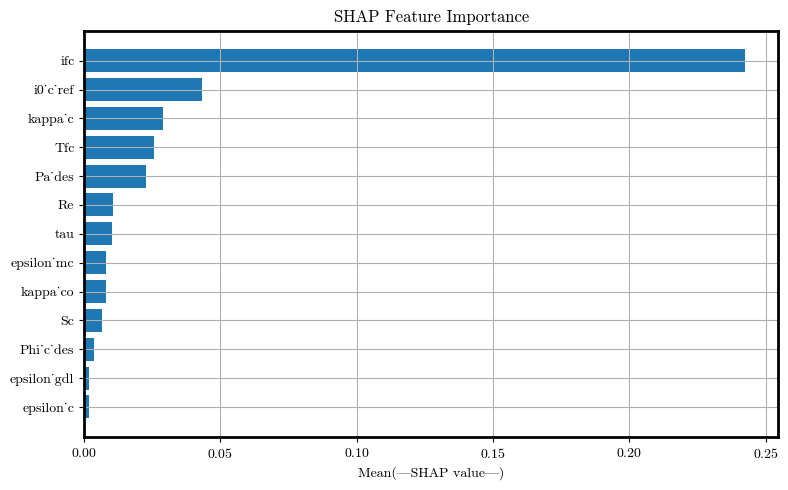

In [13]:
plot_shap_bar(FE_act_shap_results)

In [17]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_act_sobol_ = FE_act.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8717
[INFO] Sum S2 (unique pairs) = 1.1042
[INFO] Sum S1 + S2 = 1.9759 (should be ≈ 1)
[INFO] Sum ST = 1.0323 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9666
[INFO] Sum S2 (unique pairs) = 0.2224
[INFO] Sum S1 + S2 = 1.1890 (should be ≈ 1)
[INFO] Sum ST = 1.0725 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9664
[INFO] Sum S2 (unique pairs) = 0.0344
[INFO] Sum S1 + S2 = 1.0009 (should be ≈ 1)
[INFO] Sum ST = 1.0854 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9469
[INFO] Sum S2 (unique pairs) = -0.0287
[INFO] Sum S1 + S2 = 0.9182 (should be ≈ 1)
[INFO] Sum ST = 1.0710 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9497
[INFO] Sum S2 (unique pairs) = 0.0398
[INFO] Sum S1 + S2 = 0.9895 (should be ≈ 1)
[INFO] Sum ST = 1.0732 (may be > 1 due to overlaps)


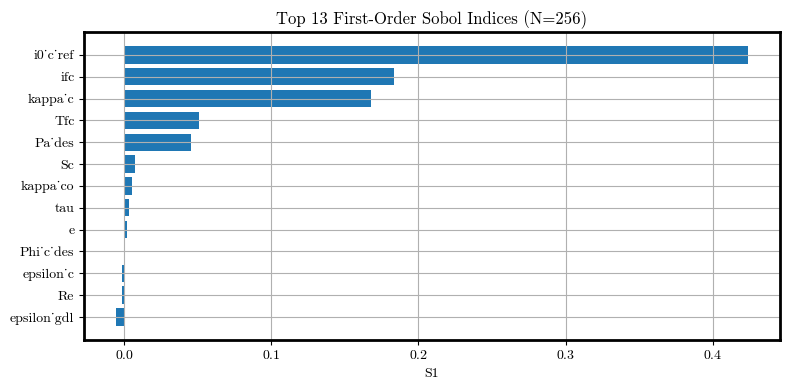

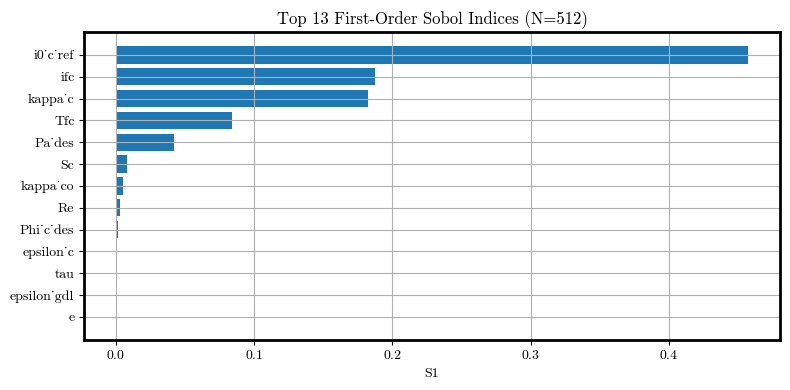

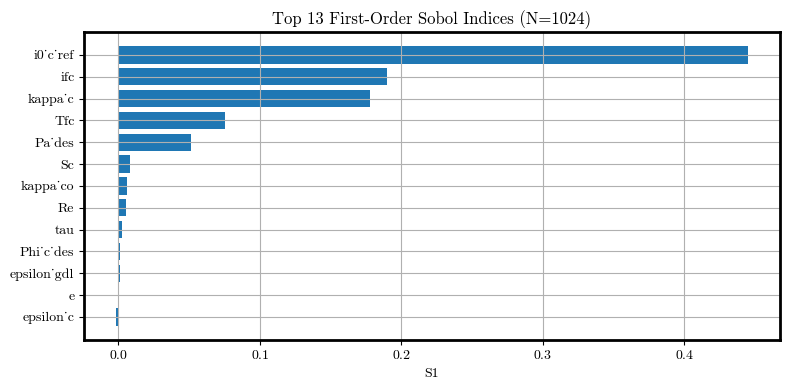

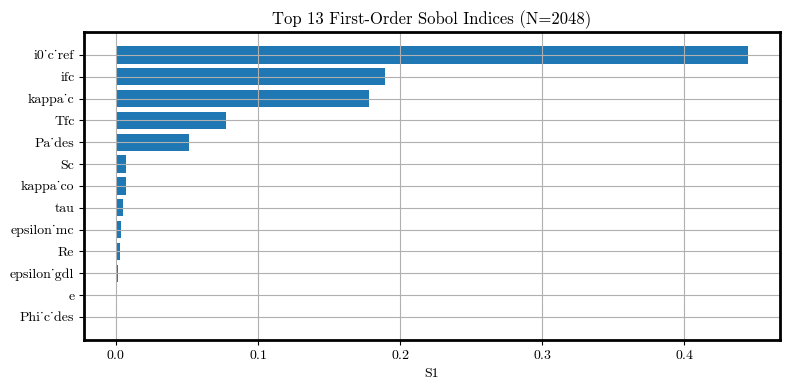

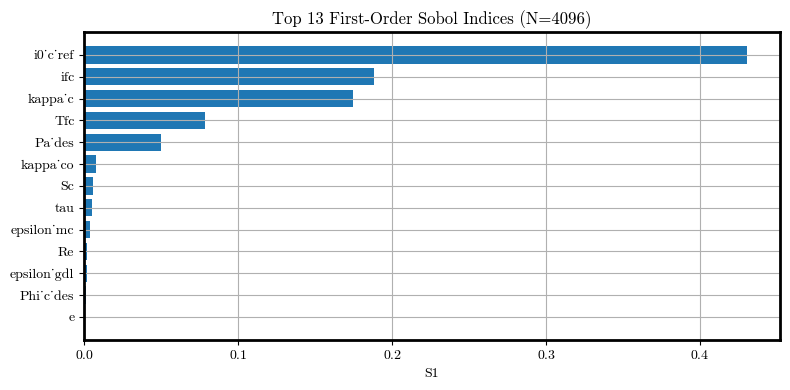

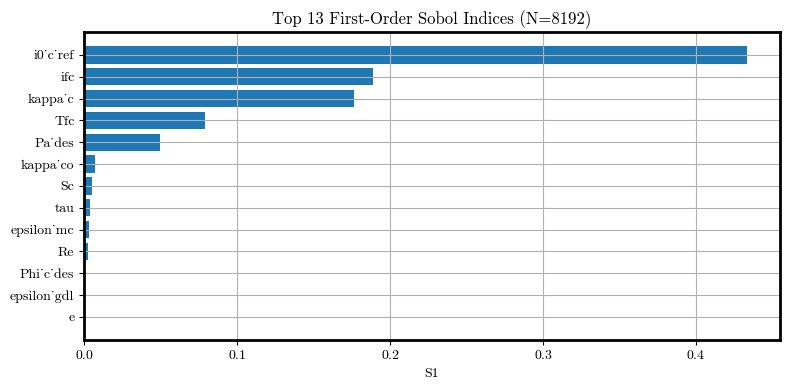

In [25]:
plot_sobol_ranking(FE_act_sobol_, top_n=13)

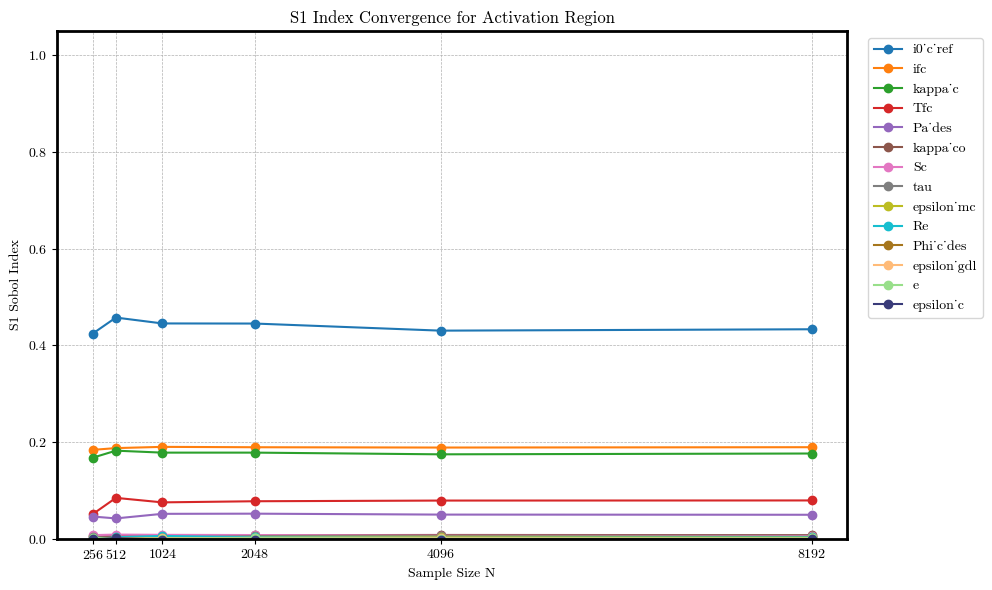

In [88]:
plot_sobol_index_convergence(FE_act_sobol_, top_k=14, index_type="S1", log_x=False, region = "Activation")

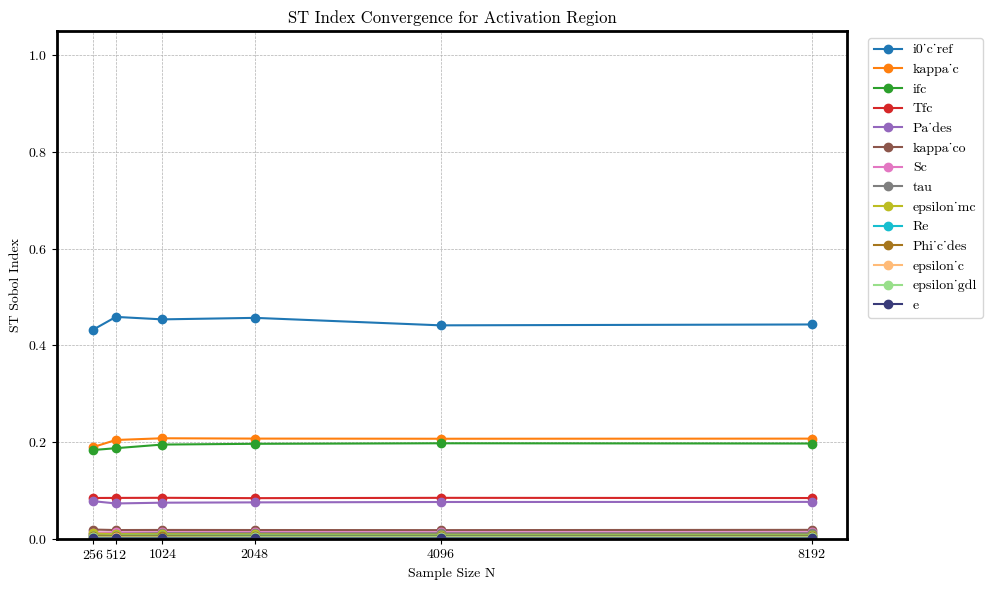

In [87]:
plot_sobol_index_convergence(FE_act_sobol_, top_k=14, index_type="ST", log_x=False, region = "Activation")

In [64]:
save_FE_results(
    region_name="activation",
    shap_df =FE_act_shap_results,
    sobol_results=FE_act_sobol_,
    save_dir="../results/sm/xgboost",
    tag="17072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_activation_17072025_shap.csv
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_activation_17072025_sobol_results.pkl


## **Ohmic**

In [30]:
FE_ohm = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="ohmic")

In [31]:
FE_ohm_shap_results = FE_ohm.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (675744 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [32]:
FE_ohm_shap_results

,feature,mean_abs_shap
13,ifc,0.068081
10,i0_c_ref,0.042955
1,Pa_des,0.030701
0,Tfc,0.030105
12,kappa_c,0.026845
9,Re,0.014886
5,tau,0.014009
6,epsilon_mc,0.011092
3,Phi_c_des,0.007050
2,Sc,0.005734


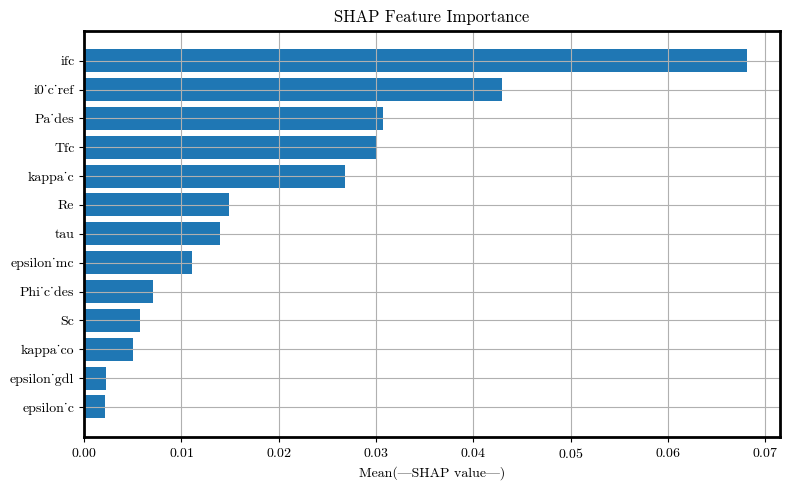

In [33]:
plot_shap_bar(FE_ohm_shap_results)

In [34]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_ohm_sobol_ = FE_ohm.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8695
[INFO] Sum S2 (unique pairs) = 1.1367
[INFO] Sum S1 + S2 = 2.0062 (should be ≈ 1)
[INFO] Sum ST = 1.0637 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9646
[INFO] Sum S2 (unique pairs) = 0.0229
[INFO] Sum S1 + S2 = 0.9875 (should be ≈ 1)
[INFO] Sum ST = 1.0985 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9501
[INFO] Sum S2 (unique pairs) = -0.0065
[INFO] Sum S1 + S2 = 0.9435 (should be ≈ 1)
[INFO] Sum ST = 1.0905 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9441
[INFO] Sum S2 (unique pairs) = -0.0666
[INFO] Sum S1 + S2 = 0.8775 (should be ≈ 1)
[INFO] Sum ST = 1.0823 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9398
[INFO] Sum S2 (unique pairs) = 0.0529
[INFO] Sum S1 + S2 = 0.9927 (should be ≈ 1)
[INFO] Sum ST = 1.0824 (may be > 1 due to overlaps)


In [35]:
FE_ohm_sobol_

{256: {'sobol_df':         feature        S1            S1_CI        ST           ST_CI  \
  0      i0_c_ref  0.307732   (0.174, 0.441)  0.310968  (0.244, 0.378)   
  1           ifc  0.243559    (0.157, 0.33)  0.256966  (0.211, 0.303)   
  2        Pa_des  0.109071   (0.041, 0.178)  0.140799  (0.108, 0.174)   
  3           Tfc  0.082820   (0.019, 0.147)  0.127938  (0.097, 0.159)   
  4       kappa_c  0.099965    (0.039, 0.16)  0.113832   (0.087, 0.14)   
  5           tau  0.006028   (-0.02, 0.033)  0.025365  (0.019, 0.032)   
  6    epsilon_mc  0.000909  (-0.026, 0.028)  0.024413  (0.017, 0.032)   
  7            Re  0.014430   (-0.012, 0.04)  0.023766  (0.017, 0.031)   
  8     Phi_c_des  0.005859  (-0.015, 0.027)  0.017774  (0.008, 0.027)   
  9            Sc  0.005432   (-0.01, 0.021)  0.008665  (0.006, 0.011)   
  10     kappa_co -0.005699  (-0.016, 0.005)  0.006351  (0.004, 0.009)   
  11  epsilon_gdl -0.006042  (-0.013, 0.001)  0.003183  (0.002, 0.004)   
  12    epsilon_c -0.

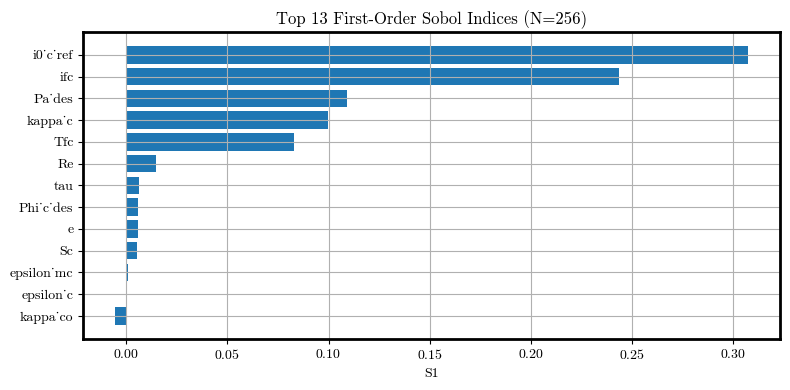

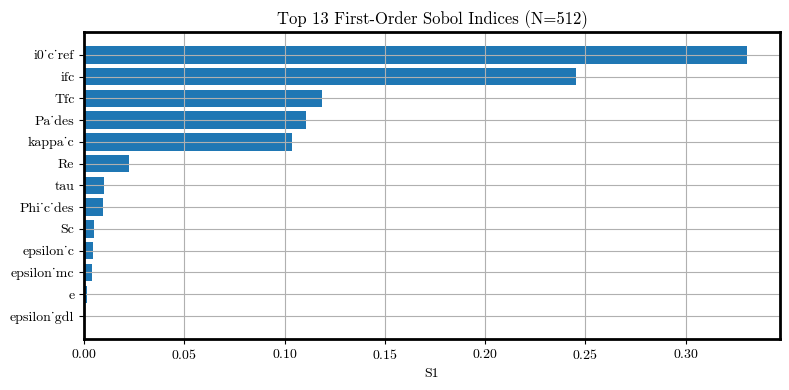

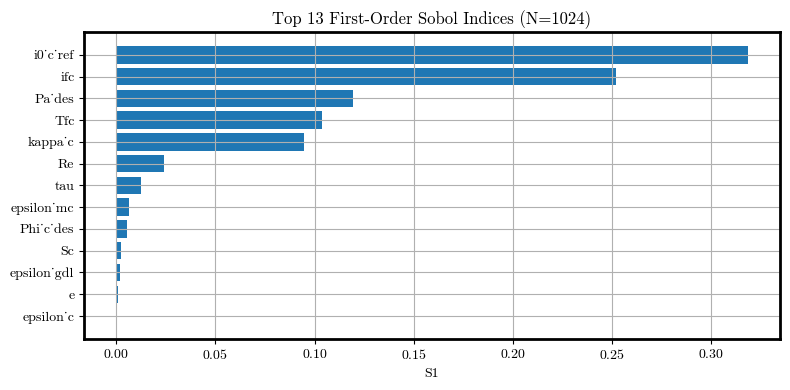

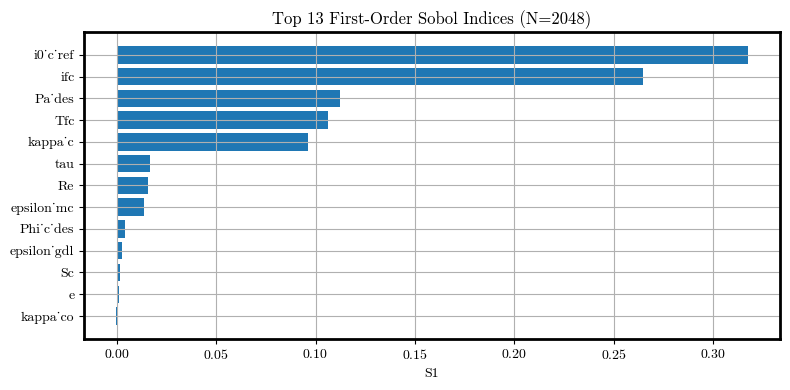

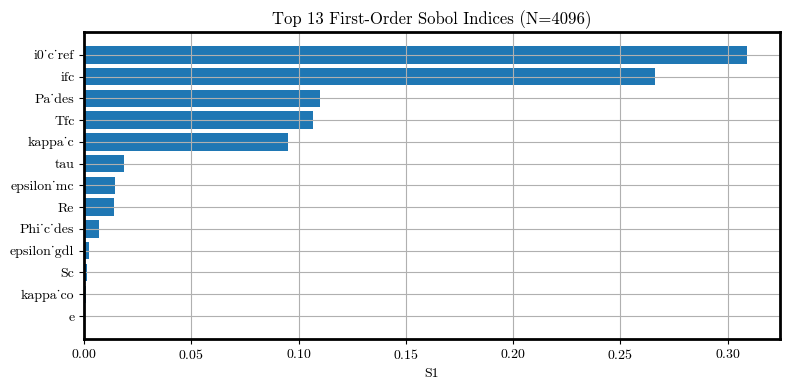

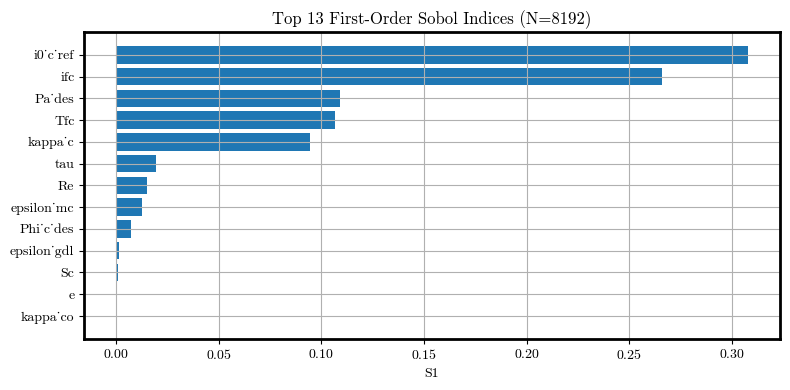

In [36]:
plot_sobol_ranking(FE_ohm_sobol_, top_n=13)

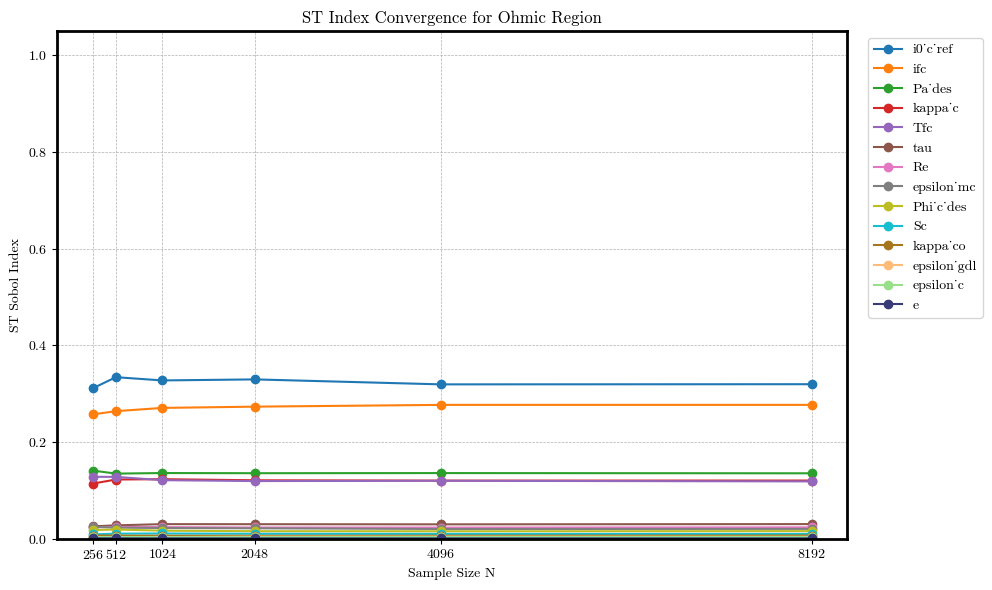

In [86]:
plot_sobol_index_convergence(FE_ohm_sobol_, top_k=14, index_type="ST", log_x=False, region = "Ohmic")

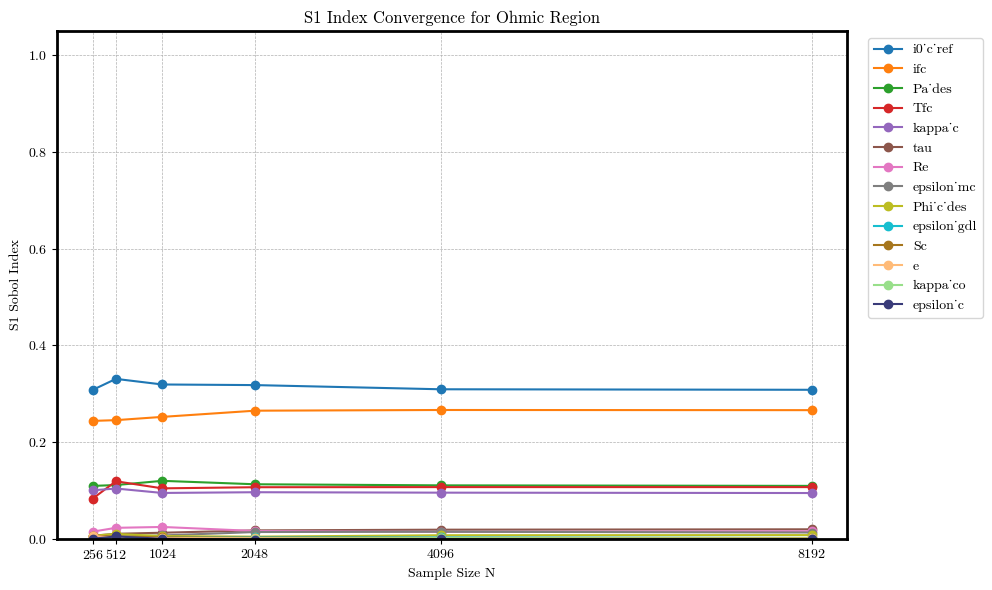

In [85]:
plot_sobol_index_convergence(FE_ohm_sobol_, top_k=14, index_type="S1", log_x=False, region = "Ohmic")

In [47]:
save_FE_results(
    region_name="ohmic",
    shap_df =FE_ohm_shap_results,
    sobol_results=FE_ohm_sobol_,
    save_dir="../results/sm/xgboost",
    tag="17072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_ohmic_17072025_shap.csv
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_ohmic_17072025_sobol_results.pkl


## **Mass transport**

In [13]:
FE_mass = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="mass_transport")

In [49]:
FE_mass_shap_results = FE_mass.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (844680 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [50]:
FE_mass_shap_results

,feature,mean_abs_shap
13,ifc,0.115942
10,i0_c_ref,0.042956
1,Pa_des,0.034779
0,Tfc,0.032639
9,Re,0.022520
12,kappa_c,0.021741
5,tau,0.018274
6,epsilon_mc,0.014542
3,Phi_c_des,0.008037
2,Sc,0.007622


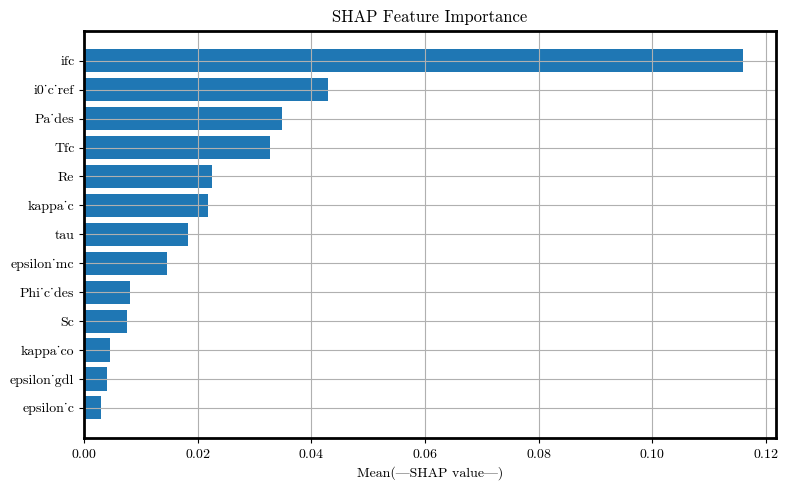

In [51]:
plot_shap_bar(FE_mass_shap_results)

In [14]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_mass_sobol_ = FE_mass.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8845
[INFO] Sum S2 (unique pairs) = 1.2074
[INFO] Sum S1 + S2 = 2.0919 (should be ≈ 1)
[INFO] Sum ST = 1.1138 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 1.0132
[INFO] Sum S2 (unique pairs) = -0.2334
[INFO] Sum S1 + S2 = 0.7798 (should be ≈ 1)
[INFO] Sum ST = 1.1742 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9217
[INFO] Sum S2 (unique pairs) = 0.0135
[INFO] Sum S1 + S2 = 0.9352 (should be ≈ 1)
[INFO] Sum ST = 1.1196 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9163
[INFO] Sum S2 (unique pairs) = -0.0001
[INFO] Sum S1 + S2 = 0.9162 (should be ≈ 1)
[INFO] Sum ST = 1.1140 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9144
[INFO] Sum S2 (unique pairs) = 0.0633
[INFO] Sum S1 + S2 = 0.9777 (should be ≈ 1)
[INFO] Sum ST = 1.1146 (may be > 1 due to overlaps)


In [15]:
FE_mass_sobol_

{256: {'sobol_df':         feature        S1            S1_CI        ST           ST_CI  \
  0      i0_c_ref  0.277224   (0.157, 0.397)  0.276933  (0.217, 0.337)   
  1           ifc  0.179146   (0.105, 0.254)  0.186428   (0.15, 0.223)   
  2        Pa_des  0.147486    (0.07, 0.225)  0.183786  (0.146, 0.222)   
  3           Tfc  0.096808   (0.031, 0.162)  0.159418  (0.123, 0.196)   
  4            Re  0.073668    (0.028, 0.12)  0.076342  (0.057, 0.095)   
  5       kappa_c  0.035825  (-0.008, 0.079)  0.057858  (0.042, 0.073)   
  6           tau  0.027822  (-0.011, 0.067)  0.051757   (0.04, 0.064)   
  7    epsilon_mc  0.024635  (-0.017, 0.066)  0.048745  (0.033, 0.064)   
  8     Phi_c_des  0.008439   (-0.02, 0.037)  0.032656  (0.013, 0.052)   
  9            Sc  0.017147  (-0.008, 0.043)  0.018414  (0.012, 0.024)   
  10  epsilon_gdl -0.007892  (-0.023, 0.007)  0.009160  (0.006, 0.013)   
  11     kappa_co -0.002140  (-0.013, 0.009)  0.007039  (0.004, 0.011)   
  12    epsilon_c -0.

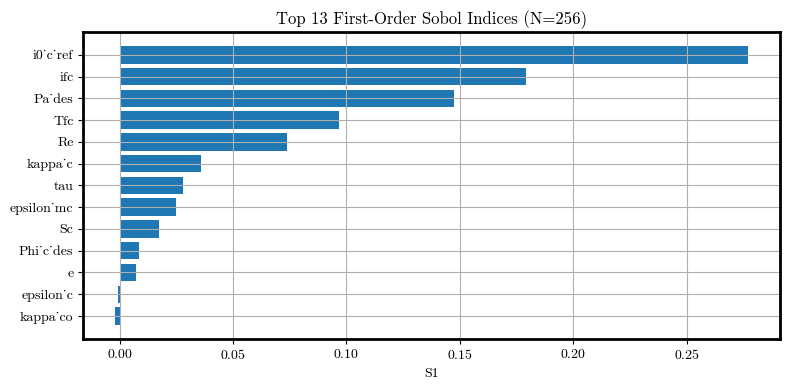

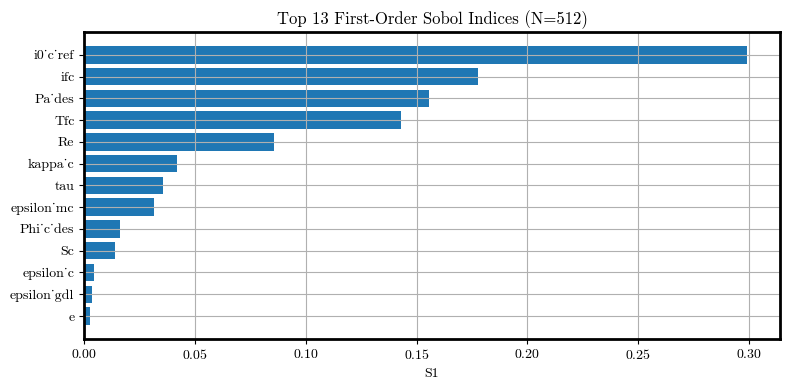

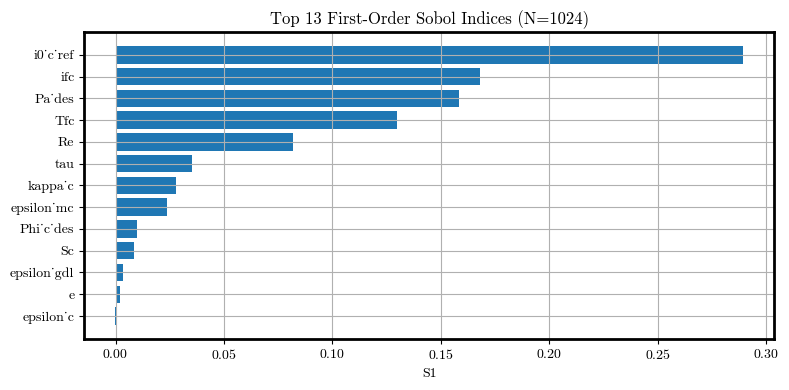

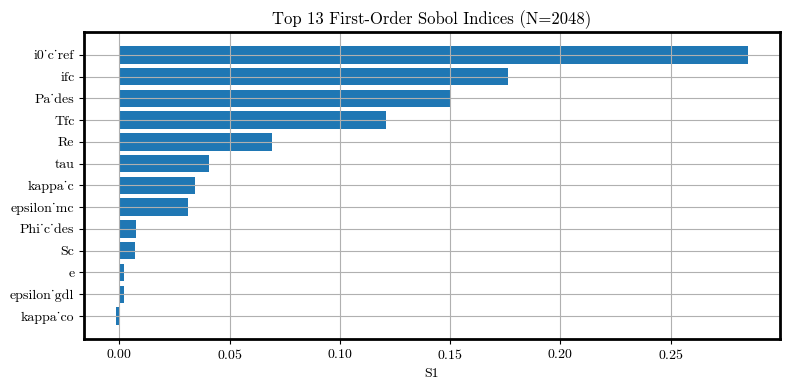

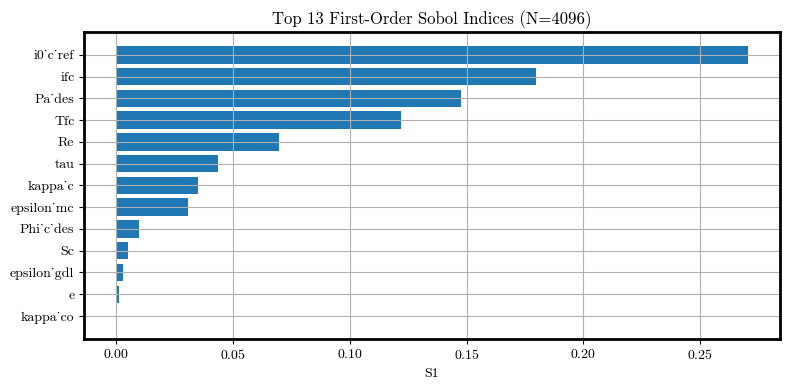

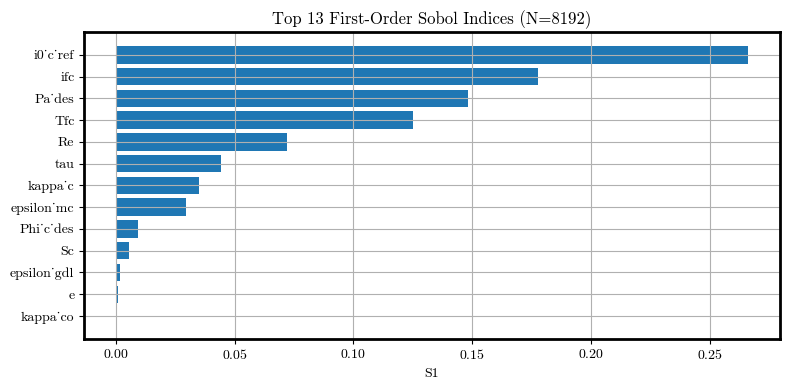

In [16]:
plot_sobol_ranking(FE_mass_sobol_, top_n=13)

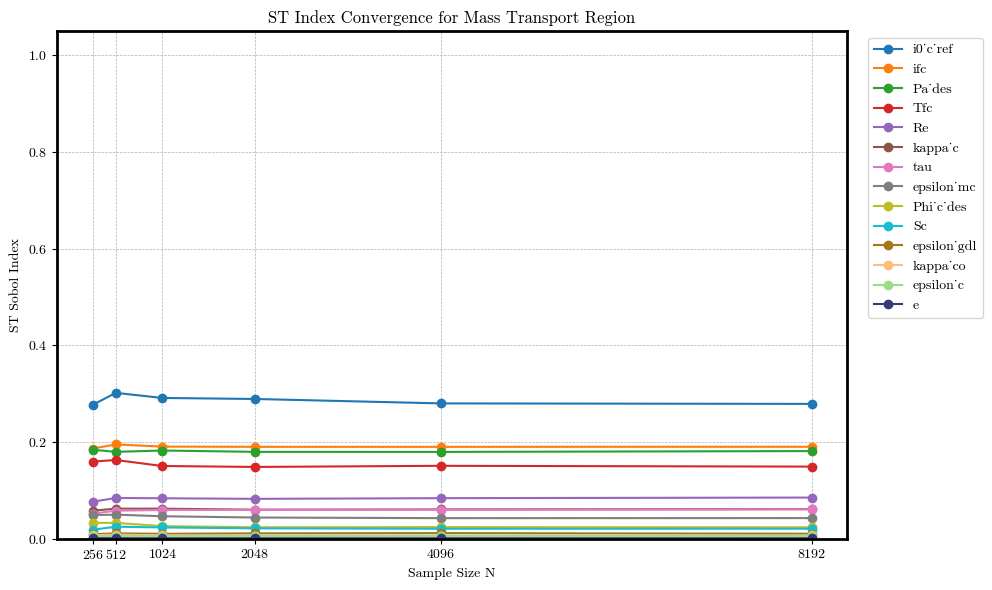

In [17]:
plot_sobol_index_convergence(FE_mass_sobol_, top_k=14, index_type="ST", log_x=False, region = "Mass Transport")

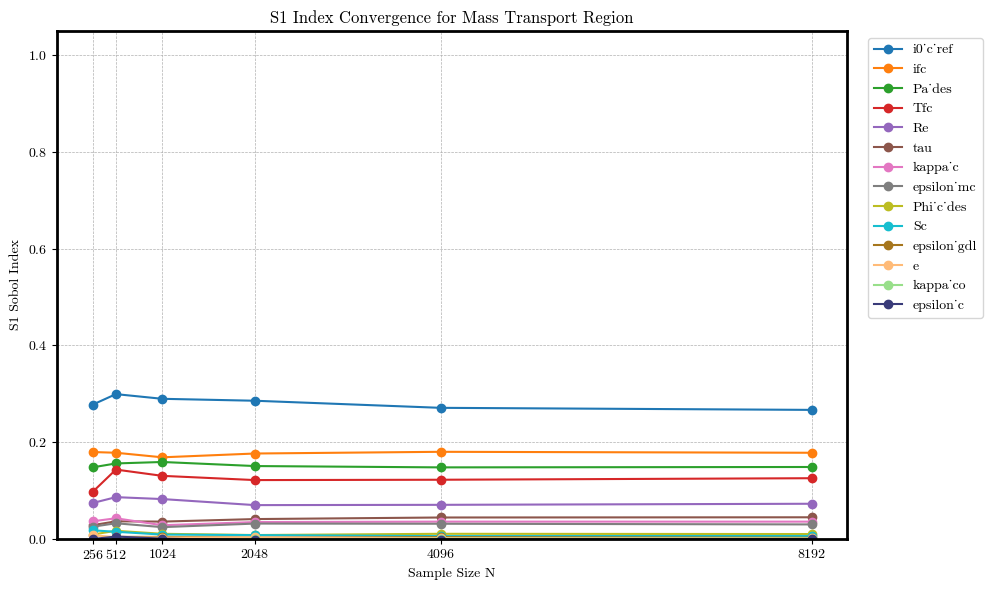

In [18]:
plot_sobol_index_convergence(FE_mass_sobol_, top_k=14, index_type="S1", log_x=False, region = "Mass Transport")

In [ ]:
save_FE_results(
    region_name="mass_transport",
    shap_df =FE_mass_shap_results,
    sobol_results=FE_mass_sobol_,
    save_dir="../results/sm/xgboost",
    tag="17072025"
)

## Read the files to get the summary

In [10]:
FE_act_shap_results,FE_act_sobol_ = load_FE_results(
    region_name="activation",
    save_dir="../results/sm/xgboost",
    tag="17072025"
)


FE_ohm_shap_results,FE_ohm_sobol_ = load_FE_results(
    region_name="ohmic",
    save_dir="../results/sm/xgboost",
    tag="17072025"
)


FE_mass_shap_results,FE_mass_sobol_ = load_FE_results(
    region_name="mass_transport",
    save_dir="../results/sm/xgboost",
    tag="17072025"
)

[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_activation_17072025_shap.csv
[INFO] Loaded Sobol results from ../results/sm/xgboost\xgb_activation_17072025_sobol_results.pkl
[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_ohmic_17072025_shap.csv
[INFO] Loaded Sobol results from ../results/sm/xgboost\xgb_ohmic_17072025_sobol_results.pkl
[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_mass_transport_17072025_shap.csv
[INFO] Loaded Sobol results from ../results/sm/xgboost\xgb_mass_transport_17072025_sobol_results.pkl


In [ ]:
df_sobol_S1 = pd.DataFrame(
    list(zip(
        FE_mass_sobol_[8192]['Si']['param'],
        FE_mass_sobol_[8192]['Si']['S1'],
        FE_mass_sobol_[8192]['Si']['S1_conf'],
        FE_mass_sobol_[8192]['Si']['ST'],
        FE_mass_sobol_[8192]['Si']['ST_conf']
    )),
    columns=['param', 'S1', 'S1_conf','ST', 'ST_conf']
)
df_sobol_S1

,param,S1,S1_conf,ST,ST_conf
0,Tfc,0.124973,0.011375,0.148972,0.006142
1,Pa_des,0.148188,0.012088,0.181104,0.007326
2,Sc,0.005447,0.004384,0.020444,0.001428
3,Phi_c_des,0.009428,0.004495,0.023353,0.001867
4,epsilon_gdl,0.001858,0.003165,0.010131,0.000778
5,tau,0.044123,0.007562,0.060464,0.002914
6,epsilon_mc,0.029365,0.006550,0.042467,0.002021
7,epsilon_c,-0.000780,0.002394,0.005598,0.000679
8,e,0.000657,0.000974,0.000852,0.000076
9,Re,0.072117,0.009009,0.084935,0.002981


In [ ]:
FE_mass_sobol_[8192]['sobol_df']

,feature,S1,S1_CI,ST,ST_CI,S2_total,S2_CI
0,i0_c_ref,0.266349,"(0.249, 0.284)",0.278743,"(0.265, 0.292)",-0.002374,"(-0.085, 0.08)"
1,ifc,0.177646,"(0.165, 0.19)",0.190026,"(0.182, 0.198)",0.000000,"(0.0, 0.0)"
2,Pa_des,0.148188,"(0.136, 0.16)",0.181104,"(0.174, 0.188)",0.013770,"(-0.228, 0.255)"
3,Tfc,0.124973,"(0.114, 0.136)",0.148972,"(0.143, 0.155)",0.011396,"(-0.209, 0.232)"
4,Re,0.072117,"(0.063, 0.081)",0.084935,"(0.082, 0.088)",-0.009561,"(-0.065, 0.046)"
5,kappa_c,0.035114,"(0.027, 0.043)",0.061085,"(0.058, 0.064)",0.001853,"(-0.01, 0.013)"
6,tau,0.044123,"(0.037, 0.052)",0.060464,"(0.058, 0.063)",0.038646,"(-0.041, 0.118)"
7,epsilon_mc,0.029365,"(0.023, 0.036)",0.042467,"(0.04, 0.044)",-0.016639,"(-0.078, 0.044)"
8,Phi_c_des,0.009428,"(0.005, 0.014)",0.023353,"(0.021, 0.025)",0.000943,"(-0.068, 0.07)"
9,Sc,0.005447,"(0.001, 0.01)",0.020444,"(0.019, 0.022)",0.012547,"(-0.057, 0.082)"


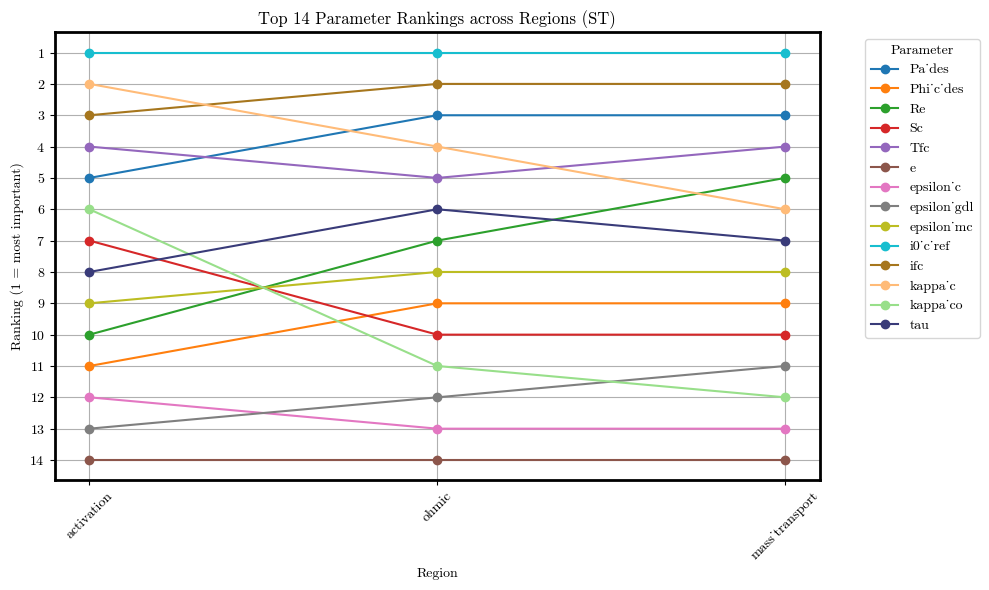

In [11]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": FE_act_sobol_[8192]["sobol_df"],
        "ohmic": FE_ohm_sobol_[8192]["sobol_df"],
        "mass_transport": FE_mass_sobol_[8192]["sobol_df"]
    },
    source_type="ST",
    top_k=14
)

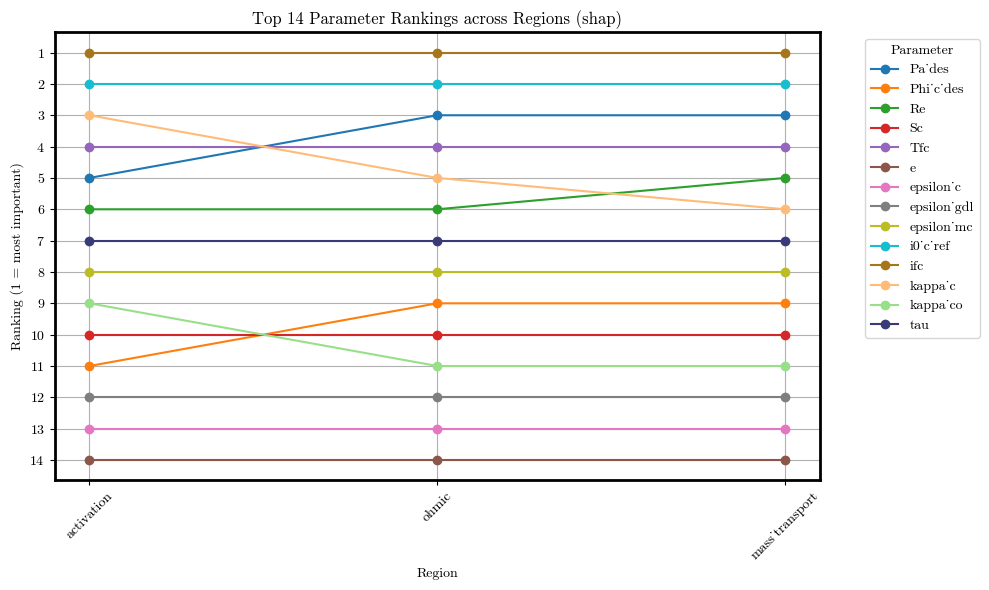

In [12]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": FE_act_shap_results,
        "ohmic": FE_ohm_shap_results,
        "mass_transport": FE_mass_shap_results
    },
    source_type="shap",
    top_k=14
)

In [13]:
select_top_features(
    rank_sources={
        "activation": FE_act_sobol_[2048]["sobol_df"],
        "ohmic": FE_ohm_sobol_[2048]["sobol_df"],
        "mass_transport": FE_mass_sobol_[2048]["sobol_df"]
    },
    source_type="ST",
    method="threshold",
    threshold=0.95,top_k=None
)


Region: activation
Selected 6 features using method='threshold' (threshold=0.95)
Total importance explained: 0.955
Selected features: ['i0_c_ref', 'kappa_c', 'ifc', 'Tfc', 'Pa_des', 'kappa_co']

Region: ohmic
Selected 8 features using method='threshold' (threshold=0.95)
Total importance explained: 0.965
Selected features: ['i0_c_ref', 'ifc', 'Pa_des', 'kappa_c', 'Tfc', 'tau', 'Re', 'epsilon_mc']

Region: mass_transport
Selected 9 features using method='threshold' (threshold=0.95)
Total importance explained: 0.960
Selected features: ['i0_c_ref', 'ifc', 'Pa_des', 'Tfc', 'Re', 'kappa_c', 'tau', 'epsilon_mc', 'Phi_c_des']

Union of all selected features across regions: ['Pa_des', 'Phi_c_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'ifc', 'kappa_c', 'kappa_co', 'tau']
Total unique features selected: 10


({'activation': ['i0_c_ref', 'kappa_c', 'ifc', 'Tfc', 'Pa_des', 'kappa_co'],
  'ohmic': ['i0_c_ref',
   'ifc',
   'Pa_des',
   'kappa_c',
   'Tfc',
   'tau',
   'Re',
   'epsilon_mc'],
  'mass_transport': ['i0_c_ref',
   'ifc',
   'Pa_des',
   'Tfc',
   'Re',
   'kappa_c',
   'tau',
   'epsilon_mc',
   'Phi_c_des']},
 {'Pa_des',
  'Phi_c_des',
  'Re',
  'Tfc',
  'epsilon_mc',
  'i0_c_ref',
  'ifc',
  'kappa_c',
  'kappa_co',
  'tau'})